# ARTI404 – Image Processing
## Lab 5: Spatial Filtering – Smoothing and Sharpening

**Student:** Mohammed Moayed Alquriniy  
**ID:** 2240007325  

**Outcome #2:** Write a program that implements fundamental image processing algorithms.

## 0. Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)
print("NumPy version :", np.__version__)

OpenCV version: 4.13.0
NumPy version : 2.4.4


## Procedural Step: Unsharp Masking
Unsharp masking sharpens an image by adding back the *detail* (original − blurred) scaled by an `amount` factor:

$$\text{sharpened} = \text{original} + \text{amount} \times (\text{original} - \text{blurred})$$

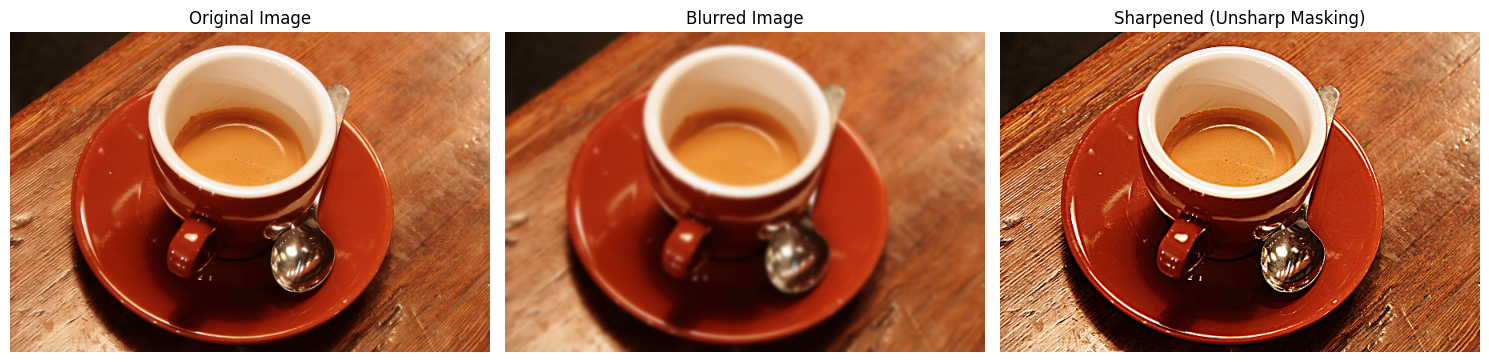

In [2]:
# Read the image
image = cv2.imread('images/Coffee.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

# Gaussian sigma
sigma = 2
# parameter
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(blurred)
ax[1].set_title("Blurred Image")
ax[1].axis("off")
ax[2].imshow(sharpened)
ax[2].set_title("Sharpened (Unsharp Masking)")
ax[2].axis("off")
plt.tight_layout()
plt.show()

## Assessment Task #1: 7×7 Box Filter
Convolve the image with a 7×7 box (mean) filter. Every output pixel is the average of its 49 neighbours, i.e. each kernel weight equals 1/49.

Box kernel (7x7):
[[0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]
 [0.0204 0.0204 0.0204 0.0204 0.0204 0.0204 0.0204]]

Max difference between filter2D and cv2.blur: 0


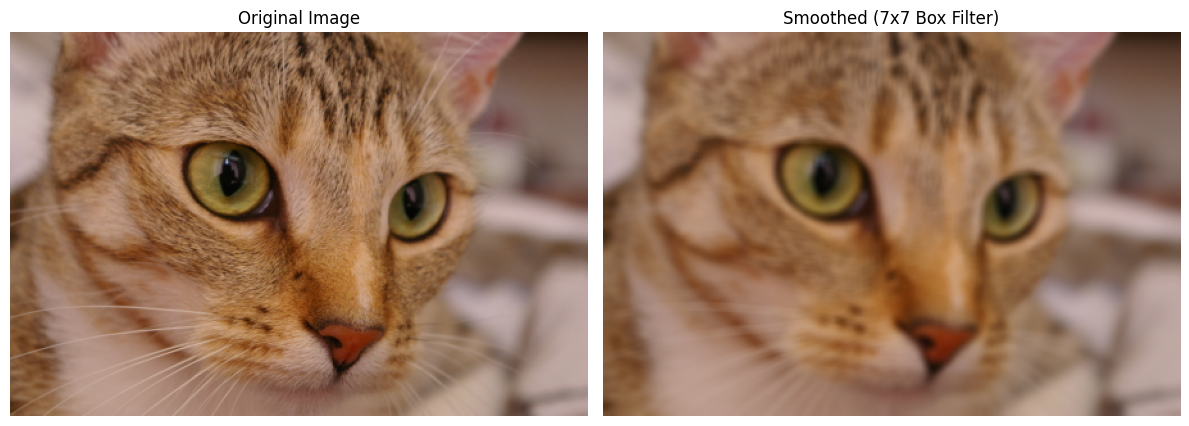

In [3]:
# Read the image
img = cv2.imread('images/Cat.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Build the 7x7 box kernel (all weights = 1/49)
box_kernel = np.ones((7, 7), np.float32) / 49
print("Box kernel (7x7):")
print(np.round(box_kernel, 4))

# Convolve the image with the kernel
box_smoothed = cv2.filter2D(img, -1, box_kernel)

# Same result using OpenCV's built-in box filter (for verification)
box_builtin = cv2.blur(img, (7, 7))
print("\nMax difference between filter2D and cv2.blur:",
      np.max(np.abs(box_smoothed.astype(int) - box_builtin.astype(int))))

# Show original and smoothed image side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(box_smoothed)
ax[1].set_title("Smoothed (7x7 Box Filter)")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## Assessment Task #2: 5×5 and 21×21 Gaussian Filters
A Gaussian filter weights the neighbours by distance from the centre, so it blurs more naturally than the box filter. A larger kernel gives a stronger blur. With `sigmaX=0`, OpenCV computes sigma from the kernel size.

Kernel 5x5 -> sigma = 1.10
Kernel 21x21 -> sigma = 3.50


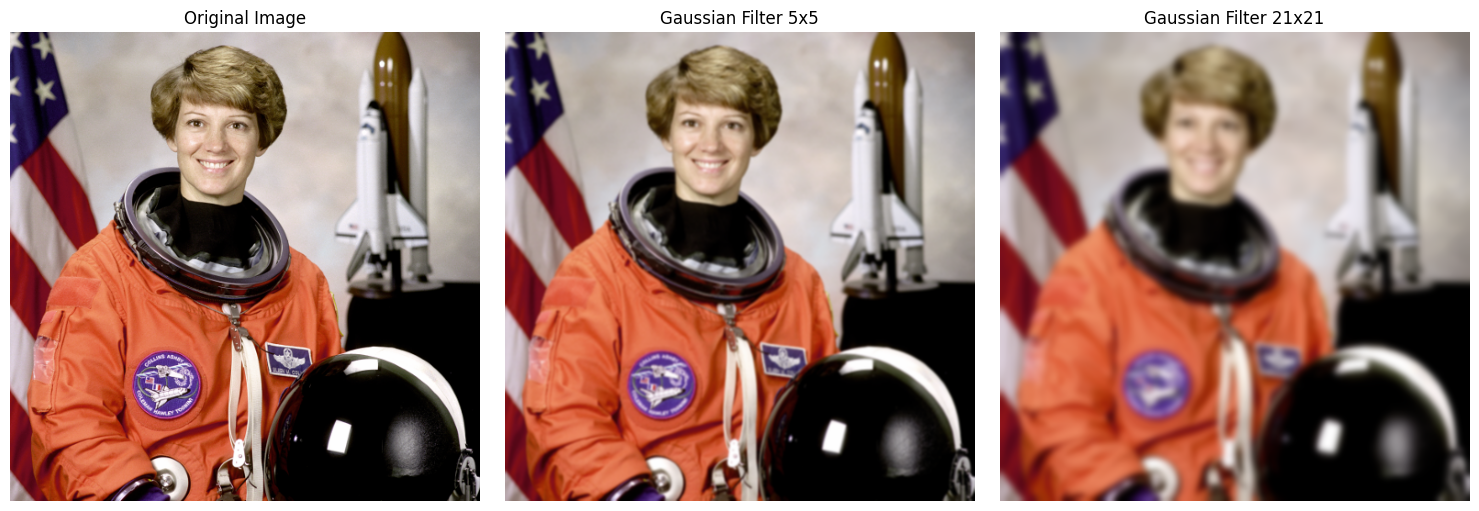

In [4]:
# Read the image
img2 = cv2.imread('images/Astronaut.png')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Apply 5x5 Gaussian filter
gauss_5 = cv2.GaussianBlur(img2, (5, 5), 0)

# Apply 21x21 Gaussian filter
gauss_21 = cv2.GaussianBlur(img2, (21, 21), 0)

# Print the sigma OpenCV used for each kernel size: 0.3*((k-1)*0.5 - 1) + 0.8
for k in (5, 21):
    print(f"Kernel {k}x{k} -> sigma = {0.3*((k-1)*0.5 - 1) + 0.8:.2f}")

# Show the three images side by side
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img2)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(gauss_5)
ax[1].set_title("Gaussian Filter 5x5")
ax[1].axis("off")
ax[2].imshow(gauss_21)
ax[2].set_title("Gaussian Filter 21x21")
ax[2].axis("off")
plt.tight_layout()
plt.show()

## Assessment Task #3: Sharpening with a 3×3 Laplacian Filter
The Laplacian is a second-derivative operator that responds strongly to edges. OpenCV's 3×3 Laplacian kernel has a **negative** centre, so the image is sharpened by **subtracting** it:

$$\text{sharpened} = \text{clip}(\text{image} - \nabla^2 \text{image},\ 0,\ 1)$$

Laplacian min / max: -2.11 / 2.11


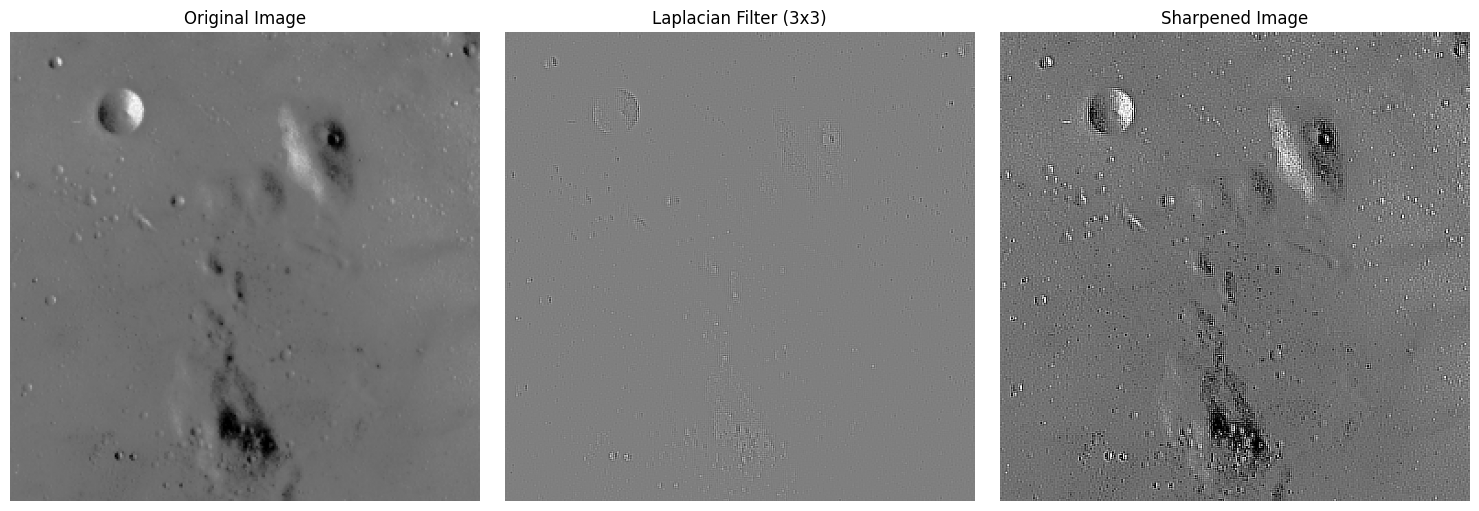

In [5]:
# Step 1: Read the image (grayscale)
img3 = cv2.imread('images/Moon.png', cv2.IMREAD_GRAYSCALE)

# Step 2: Convert image to float32 (range 0-1)
image_float = img3.astype(np.float32) / 255.0

# Step 3: Apply the 3x3 Laplacian filter
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=3)

# Step 4: Sharpen the image
sharpened = np.clip(image_float - laplacian, 0, 1)

print("Laplacian min / max:", round(float(laplacian.min()), 3), "/", round(float(laplacian.max()), 3))

# Step 5: Plot original, Laplacian result, and sharpened image
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image_float, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(laplacian, cmap='gray')
ax[1].set_title("Laplacian Filter (3x3)")
ax[1].axis("off")
ax[2].imshow(sharpened, cmap='gray')
ax[2].set_title("Sharpened Image")
ax[2].axis("off")
plt.tight_layout()
plt.show()

## Conclusion
- **Box filter (7×7):** every neighbour has equal weight, so the image becomes uniformly blurred and edges lose detail.
- **Gaussian filter:** the 5×5 kernel removes slight noise while keeping most detail; the 21×21 kernel produces a much stronger blur because the sigma grows with kernel size.
- **Unsharp masking:** subtracting a blurred copy isolates the fine details; adding them back with `amount=1.5` makes edges crisper.
- **Laplacian sharpening:** the Laplacian highlights edges (rapid intensity changes); subtracting it from the image boosts those edges, making the moon's craters noticeably sharper.
- Converting to `float32` and clipping to [0, 1] prevents overflow and negative values during filtering.